# Linear Systems
**Volume 1: Mathematical Analysis**

A **linear system** is an equation of the form $A\mathbf{x} = \mathbf{b}$, where $A$ is an $m \times n$ matrix, $\mathbf{x}$ is an unknown vector in $\mathbb{R}^n$, and $\mathbf{b}$ is a known vector in $\mathbb{R}^m$.

In this lab we implement Gaussian elimination and LU decomposition from scratch, then leverage SciPy's linear algebra routines and explore sparse matrix representations for large systems.

In [1]:
import numpy as np
import time
from scipy import linalg as la
from scipy import sparse
from matplotlib import pyplot as plt

## 1. Gaussian Elimination

**Gaussian elimination** reduces the augmented matrix $[A \mid \mathbf{b}]$ to row-echelon form (REF) using three elementary row operations:

1. Swap two rows
2. Multiply a row by a nonzero scalar
3. Add a scalar multiple of one row to another (Type III)

Once in REF we apply **back substitution** to recover $\mathbf{x}$.

### Type III Row Reduction

For a square matrix, we zero out every entry below the diagonal column-by-column:

$$A_{i,:} \leftarrow A_{i,:} - \frac{A_{i,j}}{A_{j,j}} A_{j,:}, \quad i > j$$

**Numerical caveat**: dividing by a very small pivot $A_{j,j}$ amplifies rounding errors. Production codes use *partial pivoting* (row swaps) to keep pivots large.

## Problem 1 — Gaussian Elimination

Implement `ref(A)` that reduces a square invertible matrix to REF using only Type III row operations (no row swaps). Return the modified matrix in-place (modify a copy). Verify on small random integer matrices.

In [2]:
def ref(A):
    """Reduce square invertible A to row-echelon form via Type III row ops.
    
    Returns a copy of A in REF; raises if a zero pivot is encountered.
    """
    U = A.astype(float).copy()
    m = U.shape[0]
    for j in range(m):
        for i in range(j + 1, m):
            U[i, j:] -= (U[i, j] / U[j, j]) * U[j, j:]
    return U


# --- verification ---
rng = np.random.default_rng(0)
A = rng.integers(1, 10, (4, 4)).astype(float)
U = ref(A)
print("Original A:")
print(A)
print("\nREF of A:")
print(np.round(U, 6))
# Check upper-triangular structure
assert np.allclose(np.tril(U, -1), 0), "Not upper triangular!"
print("\nAll entries below diagonal are zero: PASS")

Original A:
[[8. 6. 5. 3.]
 [3. 1. 1. 1.]
 [2. 8. 6. 9.]
 [5. 6. 9. 7.]]

REF of A:
[[ 8.000e+00  6.000e+00  5.000e+00  3.000e+00]
 [ 0.000e+00 -1.250e+00 -8.750e-01 -1.250e-01]
 [ 0.000e+00  0.000e+00  2.000e-01  7.600e+00]
 [ 0.000e+00  0.000e+00  0.000e+00 -1.585e+02]]

All entries below diagonal are zero: PASS


## 2. LU Decomposition

For an invertible matrix $A$, the **LU decomposition** factors $A = LU$ where:
- $U$ is upper triangular (the REF of $A$)
- $L$ is unit lower triangular (ones on the diagonal)

**Derivation**: each Type III elimination step is equivalent to multiplying by an elementary matrix $E_k$, so

$$E_k \cdots E_2 E_1 A = U \implies A = \underbrace{E_1^{-1} E_2^{-1} \cdots E_k^{-1}}_{L} U$$

The multipliers $\ell_{ij} = A_{i,j} / A_{j,j}$ (before elimination) slot directly into $L$:

$$L = \begin{pmatrix} 1 & & & \\ \ell_{21} & 1 & & \\ \ell_{31} & \ell_{32} & 1 & \\ \vdots & & & \ddots \end{pmatrix}$$

## Problem 2 — LU Decomposition

Implement `lu(A)` that returns $(L, U)$ for a square matrix $A$ without row swaps. Verify that $LU = A$.

In [3]:
def lu(A):
    """Compute LU decomposition A = L @ U without row swaps.
    
    Parameters
    ----------
    A : (n, n) ndarray  Square invertible matrix
    
    Returns
    -------
    L : (n, n) ndarray  Unit lower triangular
    U : (n, n) ndarray  Upper triangular
    """
    n = A.shape[0]
    U = A.astype(float).copy()
    L = np.eye(n)
    for j in range(n):
        for i in range(j + 1, n):
            L[i, j] = U[i, j] / U[j, j]
            U[i, j:] -= L[i, j] * U[j, j:]
    return L, U


# --- verification ---
rng = np.random.default_rng(42)
A = rng.random((5, 5))
L, U = lu(A)
print("L (unit lower triangular):")
print(np.round(L, 4))
print("\nU (upper triangular):")
print(np.round(U, 4))
print("\nMax reconstruction error |A - L@U|:", np.max(np.abs(A - L @ U)))
assert np.allclose(A, L @ U), "LU reconstruction failed!"
print("LU decomposition correct: PASS")

L (unit lower triangular):
[[ 1.      0.      0.      0.      0.    ]
 [ 1.2606  1.      0.      0.      0.    ]
 [ 0.4791  3.4463  1.      0.      0.    ]
 [ 0.2936  2.0477  0.3338  1.      0.    ]
 [ 0.9795 -0.3624  0.0178 -0.1031  1.    ]]

U (upper triangular):
[[ 0.774   0.4389  0.8586  0.6974  0.0942]
 [ 0.      0.2079 -0.2963 -0.751   0.3317]
 [ 0.      0.      1.2535  3.0767 -0.7447]
 [ 0.      0.      0.      1.1337  0.1734]
 [ 0.      0.      0.      0.      0.8375]]

Max reconstruction error |A - L@U|: 2.220446049250313e-16
LU decomposition correct: PASS


## 3. Solving $A\mathbf{x} = \mathbf{b}$ with LU

Given $A = LU$, the system $A\mathbf{x} = \mathbf{b}$ splits into two triangular systems:

1. **Forward substitution** — solve $L\mathbf{y} = \mathbf{b}$:
$$y_k = b_k - \sum_{j=1}^{k-1} L_{kj}\, y_j$$

2. **Backward substitution** — solve $U\mathbf{x} = \mathbf{y}$:
$$x_k = \frac{1}{U_{kk}}\!\left(y_k - \sum_{j=k+1}^{n} U_{kj}\, x_j\right)$$

Each triangular solve costs $O(n^2)$; computing the LU factorization costs $O(n^3)$. For a fixed $A$ with multiple right-hand sides $\mathbf{b}$, computing $LU$ once and reusing it is far cheaper than solving from scratch each time.

## Problem 3 — Solve $A\mathbf{x} = \mathbf{b}$

Implement `solve(A, b)` that uses `lu()` from Problem 2 plus forward and backward substitution. Verify against `np.linalg.solve()`.

In [4]:
def _forward_sub(L, b):
    """Solve Ly = b for unit lower triangular L."""
    n = len(b)
    y = np.zeros(n)
    for k in range(n):
        y[k] = b[k] - L[k, :k] @ y[:k]
    return y


def _backward_sub(U, y):
    """Solve Ux = y for upper triangular U."""
    n = len(y)
    x = np.zeros(n)
    for k in range(n - 1, -1, -1):
        x[k] = (y[k] - U[k, k+1:] @ x[k+1:]) / U[k, k]
    return x


def solve(A, b):
    """Solve Ax = b via LU decomposition + forward/backward substitution.
    
    Parameters
    ----------
    A : (n, n) ndarray  Invertible coefficient matrix
    b : (n,) ndarray    Right-hand side vector
    
    Returns
    -------
    x : (n,) ndarray    Solution vector
    """
    L, U = lu(A)
    y = _forward_sub(L, b)
    return _backward_sub(U, y)


# --- unit tests ---
def test_solve():
    rng = np.random.default_rng(7)
    for n in [3, 5, 10, 50]:
        A = rng.random((n, n)) + n * np.eye(n)  # diagonally dominant → no zero pivots
        b = rng.random(n)
        x_ours = solve(A, b)
        x_ref  = np.linalg.solve(A, b)
        assert np.allclose(x_ours, x_ref, atol=1e-10), f"FAIL for n={n}"
        print(f"n={n:3d}  max error = {np.max(np.abs(x_ours - x_ref)):.2e}  PASS")

test_solve()

n=  3  max error = 6.94e-18  PASS
n=  5  max error = 2.78e-17  PASS
n= 10  max error = 1.39e-17  PASS
n= 50  max error = 1.04e-17  PASS


## 4. SciPy Linear Algebra

SciPy's `linalg` module wraps highly optimised LAPACK routines. Key functions for linear systems:

| Function | Purpose |
|---|---|
| `la.solve(A, b)` | Solve $A\mathbf{x}=\mathbf{b}$ (uses LU internally) |
| `la.lu_factor(A)` | Factorise $A = PLU$ once |
| `la.lu_solve((lu, piv), b)` | Solve with precomputed factorisation |
| `la.inv(A)` | Matrix inverse (avoid for solving systems) |

**Rule of thumb**: never compute $A^{-1}$ just to solve a system — `la.solve()` is faster and more accurate. Use `lu_factor` + `lu_solve` when the same $A$ appears with many different $\mathbf{b}$'s.

## Problem 4 — Solver Performance Comparison

Compare four strategies for solving $A\mathbf{x} = \mathbf{b}$ as $n$ grows:

1. `la.inv(A) @ b` (matrix inversion)
2. `la.solve(A, b)`
3. `la.lu_factor` + `la.lu_solve` (factorisation **included** in timing)
4. `la.lu_factor` + `la.lu_solve` (factorisation **excluded** from timing)

Plot wall-clock time vs. $n$ on a log-log scale.

n=50
n=100
n=200
n=400


n=800


n=1500


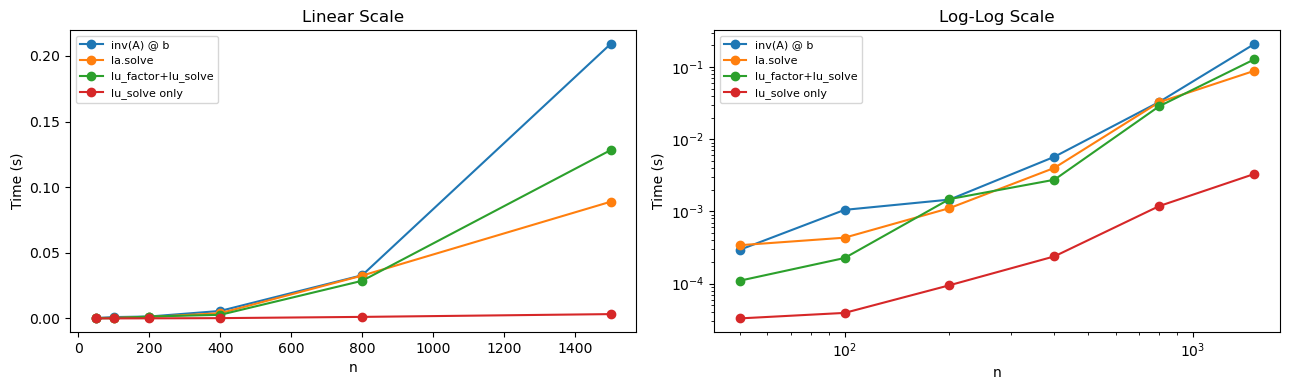

In [5]:
def prob4():
    sizes = [50, 100, 200, 400, 800, 1500]
    t_inv, t_solve, t_lu_total, t_lu_solve = [], [], [], []

    for n in sizes:
        rng = np.random.default_rng(n)
        A = rng.random((n, n)) + n * np.eye(n)
        b = rng.random(n)

        reps = max(1, 1000 // n)

        # Method 1: inverse
        start = time.perf_counter()
        for _ in range(reps):
            la.inv(A) @ b
        t_inv.append((time.perf_counter() - start) / reps)

        # Method 2: la.solve
        start = time.perf_counter()
        for _ in range(reps):
            la.solve(A, b)
        t_solve.append((time.perf_counter() - start) / reps)

        # Method 3: lu_factor + lu_solve (both timed)
        start = time.perf_counter()
        for _ in range(reps):
            lu_piv = la.lu_factor(A)
            la.lu_solve(lu_piv, b)
        t_lu_total.append((time.perf_counter() - start) / reps)

        # Method 4: lu_solve only (factor computed once outside timing)
        lu_piv = la.lu_factor(A)
        start = time.perf_counter()
        for _ in range(reps):
            la.lu_solve(lu_piv, b)
        t_lu_solve.append((time.perf_counter() - start) / reps)

        print(f"n={n}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    labels = ["inv(A) @ b", "la.solve", "lu_factor+lu_solve", "lu_solve only"]
    data   = [t_inv, t_solve, t_lu_total, t_lu_solve]

    for ax in axes:
        for d, lbl in zip(data, labels):
            ax.plot(sizes, d, marker='o', label=lbl)
        ax.set_xlabel("n")
        ax.set_ylabel("Time (s)")
        ax.legend(fontsize=8)

    axes[0].set_title("Linear Scale")
    axes[1].set_xscale("log"); axes[1].set_yscale("log")
    axes[1].set_title("Log-Log Scale")

    plt.tight_layout()
    plt.show()

prob4()

## 5. Sparse Matrices

A matrix is **sparse** if most of its entries are zero. Storing a $10^5 \times 10^5$ dense matrix would require $\approx 40\,\text{GB}$ of RAM. Sparse formats store only the nonzero values.

### Common SciPy sparse formats

| Format | Best for |
|---|---|
| `coo_array` | Construction from (row, col, val) triples |
| `csr_array` | Arithmetic and row slicing |
| `csc_array` | Column slicing |
| `dia_array` | Diagonal-heavy matrices (e.g. FD/FEM stencils) |
| `lil_array` | Incremental construction |

### Construction examples

```python
from scipy import sparse

# Coordinate format
rows = [0, 1, 0]
cols = [0, 1, 1]
vals = [3, 5, 2]
A = sparse.coo_array((vals, (rows, cols)), shape=(3, 3))

# Diagonal format
diags = [[1, 2], [3, 4, 5], [6]]
offsets = [-1, 0, 3]
B = sparse.diags(diags, offsets, shape=(3, 4))
```

## Problem 5 — Sparse Matrix Construction

Build and visualise a block-diagonal sparse matrix, then a tridiagonal matrix representing a 1-D finite-difference Laplacian.

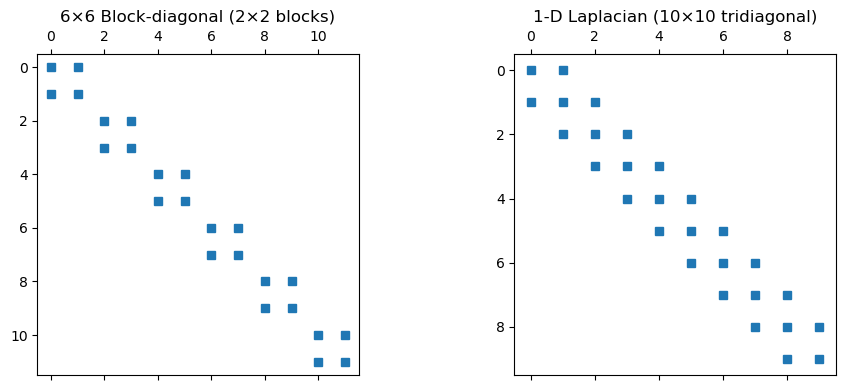

Block-diagonal nnz: 24  (dense size: 144 )
Laplacian nnz:      28  (dense size: 100 )


In [6]:
# --- 5a: Block-diagonal matrix ---
block = sparse.coo_array(np.array([[1, 2], [3, 4]], dtype=float))
A_block = sparse.block_diag([block] * 6)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].spy(A_block, markersize=6)
axes[0].set_title("6×6 Block-diagonal (2×2 blocks)")

# --- 5b: Tridiagonal 1-D Laplacian  D²u ≈ (u_{i-1}-2u_i+u_{i+1})/h² ---
n = 10
main  = -2 * np.ones(n)
off   =  1 * np.ones(n - 1)
L = sparse.diags([off, main, off], [-1, 0, 1], shape=(n, n), format="csr")

axes[1].spy(L, markersize=6)
axes[1].set_title(f"1-D Laplacian ({n}×{n} tridiagonal)")

plt.tight_layout()
plt.show()

print("Block-diagonal nnz:", A_block.nnz, " (dense size:", A_block.shape[0]*A_block.shape[1], ")")
print("Laplacian nnz:     ", L.nnz,       " (dense size:", n*n, ")")

## Problem 6 — Sparse vs. Dense Operations

Solve a large tridiagonal system with both a sparse solver and a dense solver, and compare timing and memory.

In [7]:
from scipy.sparse import linalg as spla

def compare_sparse_dense(n):
    """Solve the 1-D Laplacian system with sparse and dense solvers."""
    main = -2 * np.ones(n)
    off  =  1 * np.ones(n - 1)
    L_sparse = sparse.diags([off, main, off], [-1, 0, 1], shape=(n, n), format="csc")
    L_dense  = L_sparse.toarray()
    b = np.random.default_rng(0).random(n)

    # Sparse solve
    t0 = time.perf_counter()
    x_sp = spla.spsolve(L_sparse, b)
    t_sparse = time.perf_counter() - t0

    # Dense solve
    t0 = time.perf_counter()
    x_dn = la.solve(L_dense, b)
    t_dense = time.perf_counter() - t0

    err = np.max(np.abs(x_sp - x_dn))
    print(f"n={n:5d}  sparse={t_sparse*1e3:7.2f} ms  dense={t_dense*1e3:7.2f} ms  "
          f"speedup={t_dense/t_sparse:5.1f}x  max_err={err:.2e}")

print(f"{'n':>5}  {'sparse':>10}  {'dense':>10}  {'speedup':>8}  max_err")
print("-" * 58)
for n in [100, 500, 1000, 2000]:
    compare_sparse_dense(n)

    n      sparse       dense   speedup  max_err
----------------------------------------------------------
n=  100  sparse=   0.95 ms  dense=   0.70 ms  speedup=  0.7x  max_err=3.41e-13
n=  500  sparse=   0.49 ms  dense=   1.07 ms  speedup=  2.2x  max_err=1.46e-11
n= 1000  sparse=   0.69 ms  dense=   2.40 ms  speedup=  3.5x  max_err=1.46e-11
n= 2000  sparse=   1.19 ms  dense=   9.51 ms  speedup=  8.0x  max_err=2.62e-10


### Timing curves: sparse vs. dense for the Laplacian system

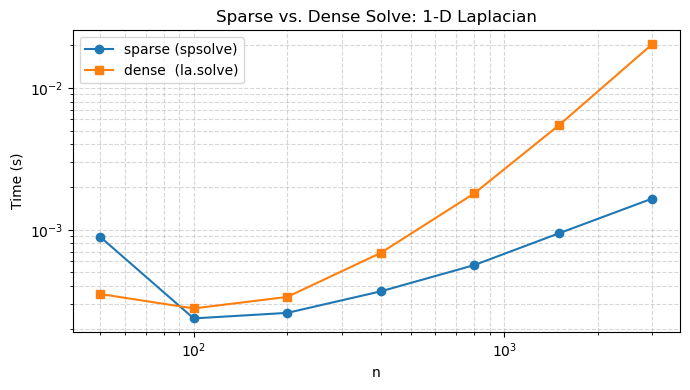

In [8]:
sizes = [50, 100, 200, 400, 800, 1500, 3000]
t_sp, t_dn = [], []

for n in sizes:
    main = -2 * np.ones(n)
    off  =  1 * np.ones(n - 1)
    L_sp = sparse.diags([off, main, off], [-1, 0, 1], shape=(n, n), format="csc")
    L_dn = L_sp.toarray()
    b    = np.random.default_rng(1).random(n)

    t0 = time.perf_counter(); spla.spsolve(L_sp, b); t_sp.append(time.perf_counter() - t0)
    t0 = time.perf_counter(); la.solve(L_dn, b);     t_dn.append(time.perf_counter() - t0)

plt.figure(figsize=(7, 4))
plt.loglog(sizes, t_sp, 'o-', label="sparse (spsolve)")
plt.loglog(sizes, t_dn, 's-', label="dense  (la.solve)")
plt.xlabel("n"); plt.ylabel("Time (s)")
plt.title("Sparse vs. Dense Solve: 1-D Laplacian")
plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout(); plt.show()